In [6]:
from pathlib import Path  # filesystem paths
import pandas as pd  # tabular data handling
import numpy as np  # numerical arrays
import matplotlib.pyplot as plt  # plotting interface
import seaborn as sns  # statistical visualizations

from sklearn.cluster import KMeans  # k-means clustering
from sklearn.metrics import silhouette_score  # silhouette metric for clustering quality
from sklearn.decomposition import PCA  # dimensionality reduction for plotting

In [ ]:
PROJECT_ROOT = Path().resolve().parent # project root (one level up)
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" # processed data directory
DATA_RAW = PROJECT_ROOT / "data" / "raw"
PLOTS_DIR = PROJECT_ROOT / "reports" / "Models" /"KMeans" # clustering plots output
PLOTS_DIR.mkdir(parents=True, exist_ok=True) # ensure output folder exists


In [7]:

def run_kmeans_for(dataset: str = "mat") -> None:

    if dataset not in {"mat", "por"}:
        raise ValueError("dataset must be 'mat' or 'por'")

    df = pd.read_csv(DATA_PROCESSED / f"processed_{dataset}.csv")
    X = df.drop(columns=["G3"])   # remove target for unsupervised clustering

    print(f"[{dataset}] shape of processed feature matrix:", X.shape)

    k_values = range(2, 9)
    sil_scores = []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        sil_scores.append(score)

    plt.figure(figsize=(7, 5))
    plt.plot(k_values, sil_scores, marker="o")
    plt.title(f"Silhouette Score vs K (student-{dataset})")
    plt.xlabel("Number of clusters (K)")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"silhouette_{dataset}.png", dpi=300)
    plt.show()

    best_k = k_values[int(np.argmax(sil_scores))]
    print(f"[{dataset}] best K according to silhouette:", best_k)

    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
    cluster_labels = kmeans.fit_predict(X)
    df["cluster"] = cluster_labels

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                    hue=cluster_labels, palette="tab10")
    plt.title(f"KMeans Clusters (k={best_k}) with PCA 2D — student-{dataset}")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"kmeans_pca_{dataset}_k{best_k}.png", dpi=300)
    plt.show()

    cluster_summary = df.groupby("cluster").mean().round(3)
    print(f"\n[{dataset}] cluster feature means:\n")
    display(cluster_summary)

    cluster_summary.to_csv(
        PLOTS_DIR / f"cluster_feature_means_{dataset}.csv"
    )

    raw_path = DATA_RAW / f"student-{dataset}.csv"
    raw_df = pd.read_csv(raw_path, sep=";")

    df["pass"] = (raw_df["G3"] >= 10).astype(int)

    cluster_pass_rate = df.groupby("cluster")["pass"].mean().rename("pass_rate")
    print(f"\n[{dataset}] pass rate per cluster:\n")
    display(cluster_pass_rate.to_frame())

    cluster_pass_rate.to_csv(
        PLOTS_DIR / f"cluster_pass_rate_{dataset}.csv"
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(cluster_summary, cmap="viridis")
    plt.title(f"Cluster Feature Means Heatmap (student-{dataset})")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"cluster_heatmap_{dataset}.png", dpi=300)
    plt.show()

[por] shape of processed feature matrix: (649, 46)


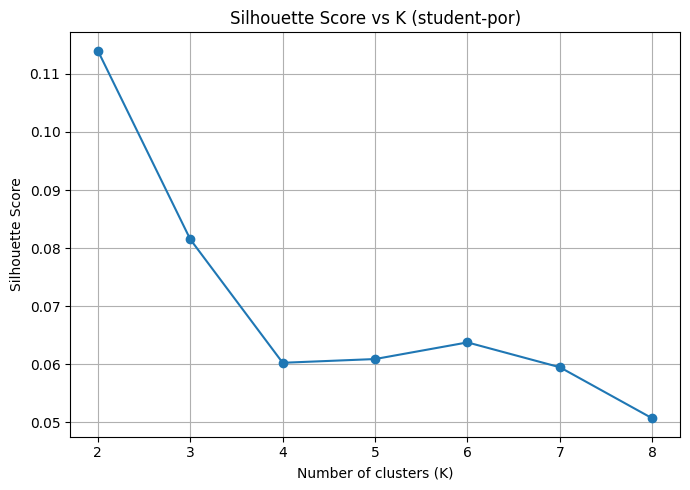

[por] best K according to silhouette: 2


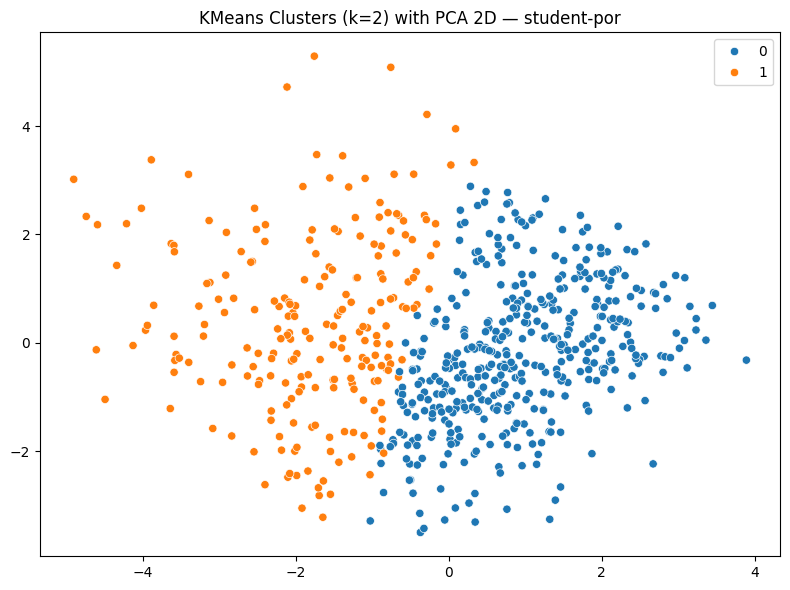


[por] cluster feature means:



,sex_M,address_U,famsize_LE3,Pstatus_T,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.336,0.773,0.294,0.864,0.119,0.638,0.054,0.488,0.822,0.974,...,0.036,-0.264,-0.209,-0.354,-0.373,-0.103,-0.321,0.458,0.510,0.581
1,0.552,0.548,0.299,0.900,0.077,0.566,0.072,0.480,0.765,0.738,...,-0.115,0.349,0.606,0.756,0.699,0.161,-0.132,-0.453,-0.318,-0.168



[por] pass rate per cluster:



,pass_rate
cluster,
0,0.946262
1,0.651584


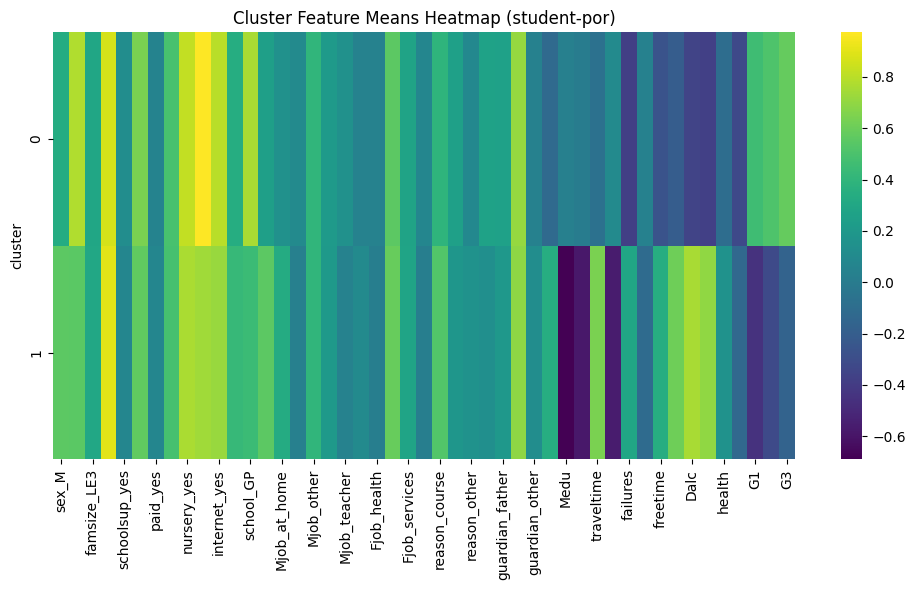

In [8]:
run_kmeans_for("por")

In [ ]:
run_kmeans_for("mat")